# Homework 07 — Outliers + Risk Assumptions
**Name:** Jesse Wang
**Date:** 2026-08-20

## Objectives
- Improve the reusable outlier-detection / -handling functions in `src/outliers.py`.
- Apply IQR and Z-score detection to a numeric column and create boolean flags.
- Run a sensitivity analysis (summary stats **and** linear regression) across three
  treatments: **all** data, **IQR-filtered**, and **winsorized**.
- Reflect on the assumptions and risks behind each method and threshold.

In [1]:
# --- packages this notebook needs (uncomment and run once, then re-comment) ---
# !pip install numpy pandas matplotlib scikit-learn

In [2]:
# Setup — generate the synthetic dataset (run once)
import os
import numpy as np
import pandas as pd

# Folders relative to THIS notebook (meant to be run from homework7/)
raw_dir = 'data/raw'
processed_dir = 'data/processed'
os.makedirs(raw_dir, exist_ok=True)
os.makedirs(processed_dir, exist_ok=True)

# Business-day dates, 2022-01-03 .. 2022-06-10
dates = pd.date_range(start="2022-01-03", end="2022-06-10", freq="B")

np.random.seed(17)  # fixed seed for reproducibility

# daily_return ~ N(0, 0.01), shifted slightly lower before May
returns = np.random.normal(0, 0.01, size=len(dates))
returns[dates < "2022-05-01"] -= 0.0015

# Five large "shock" values injected in May
shock_values = {
    "2022-05-02":  0.1748425237194541,
    "2022-05-03": -0.16825801732486943,
    "2022-05-06": -0.19667220757153227,
    "2022-05-09":  0.21240223590614747,
    "2022-05-12": -0.178729287231294,
}
for d, v in shock_values.items():
    returns[np.where(dates == pd.to_datetime(d))[0][0]] = v

# daily_return_2 is correlated with daily_return + small noise (true slope 0.6)
daily_return_2 = returns * 0.6 + np.random.normal(0, 0.005, size=len(dates))

df = pd.DataFrame({"date": dates, "daily_return": returns, "daily_return_2": daily_return_2})

csv_path = os.path.join(raw_dir, 'outliers_homework.csv')  # single source of truth for the filename
if not os.path.exists(csv_path):
    df.to_csv(csv_path, index=False)
    print(f'Synthetic dataset saved to {csv_path}')
else:
    print(f'File already exists at {csv_path}. Skipping to avoid overwrite.')

File already exists at data/raw/outliers_homework.csv. Skipping to avoid overwrite.


In [3]:
# Imports + config
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

from src import outliers   # our improved functions (see section 2)

np.random.seed(17)
%matplotlib inline

## 1) Load the dataset

In [4]:
data_path = Path(csv_path)   # csv_path was defined in the Setup cell above
df = pd.read_csv(data_path, parse_dates=['date'])
print('shape:', df.shape)
print('missing values:', int(df.isna().sum().sum()))   # this stage is about outliers, not missingness
df.head()

shape: (115, 3)
missing values: 0


,date,daily_return,daily_return_2
0,2022-01-03,0.001263,0.003834
1,2022-01-04,-0.020046,-0.009506
2,2022-01-05,0.004739,-0.000535
3,2022-01-06,0.009953,0.012539
4,2022-01-07,0.008872,0.009840


## 2) Improved outlier functions (imported from `src/outliers.py`)

The starter implementations worked, but silently accepted an empty series, said nothing
about `NaN`, used the population standard deviation without explanation, and never checked
that `k` / `threshold` are positive (or that `winsorize_series` got `lower < upper`).

The improved versions in [`src/outliers.py`](src/outliers.py):

* return an explicit **all-`False` mask** for empty / all-`NaN` / constant input (no more
  "accidentally False" behaviour);
* compute statistics on the **non-null values only**, and never flag a `NaN` as an outlier;
* use `ddof=0` (population std) **and document why** — a Z-score judges each observation
  against the spread of the data we actually hold;
* **validate inputs** (`k > 0`, `threshold > 0`, `0 <= lower < upper <= 1`).

The quick checks below exercise exactly those edge cases.

In [5]:
# Edge-case checks for the improved functions
s = df['daily_return']

# NaN is never flagged; empty series -> explicit all-False mask
with_nan = pd.Series([0.0, 0.01, np.nan, 0.02])
print('IQR on [0, 0.01, NaN, 0.02]:', outliers.detect_outliers_iqr(with_nan).tolist())
print('IQR on empty series        :', outliers.detect_outliers_iqr(pd.Series(dtype=float)).tolist())

# Invalid parameters raise instead of silently misbehaving
for fn, bad in [
    (outliers.detect_outliers_iqr,   dict(k=-1)),
    (outliers.detect_outliers_zscore, dict(threshold=0)),
    (outliers.winsorize_series,      dict(lower=0.9, upper=0.1)),
]:
    try:
        fn(s, **bad)
        print(f'{fn.__name__} accepted {bad} (unexpected)')
    except ValueError as e:
        print(f'{fn.__name__} rejects {bad}: {e}')

IQR on [0, 0.01, NaN, 0.02]: [False, False, False, False]
IQR on empty series        : []
detect_outliers_iqr rejects {'k': -1}: k must be a positive number; got -1
detect_outliers_zscore rejects {'threshold': 0}: threshold must be a positive number; got 0
winsorize_series rejects {'lower': 0.9, 'upper': 0.1}: Require 0 <= lower < upper <= 1; got lower=0.9, upper=0.1


## 3) Detect outliers & create flags

I apply both detectors to `daily_return` — the column that contains the five injected shocks.

In [6]:
target_col = 'daily_return'

df['outlier_iqr'] = outliers.detect_outliers_iqr(df[target_col], k=1.5)
df['outlier_z']   = outliers.detect_outliers_zscore(df[target_col], threshold=3.0)

flag_summary = pd.DataFrame({
    'flagged':  [int(df['outlier_iqr'].sum()), int(df['outlier_z'].sum())],
    'fraction': [df['outlier_iqr'].mean(),     df['outlier_z'].mean()],
}, index=['IQR (k=1.5)', 'Z-score (threshold=3)'])
flag_summary

,flagged,fraction
IQR (k=1.5),9,0.078261
Z-score (threshold=3),5,0.043478


In [7]:
# Which dates does each method flag? (the five injected shocks are in May)
df.loc[df['outlier_iqr'] | df['outlier_z'],
       ['date', target_col, 'outlier_iqr', 'outlier_z']].sort_values('date')

,date,daily_return,outlier_iqr,outlier_z
41,2022-03-01,0.031952,True,False
63,2022-03-31,-0.031101,True,False
85,2022-05-02,0.174843,True,True
86,2022-05-03,-0.168258,True,True
87,2022-05-04,-0.033999,True,False
89,2022-05-06,-0.196672,True,True
90,2022-05-09,0.212402,True,True
92,2022-05-11,0.028711,True,False
93,2022-05-12,-0.178729,True,True


## 4) Visual checks (before / after)

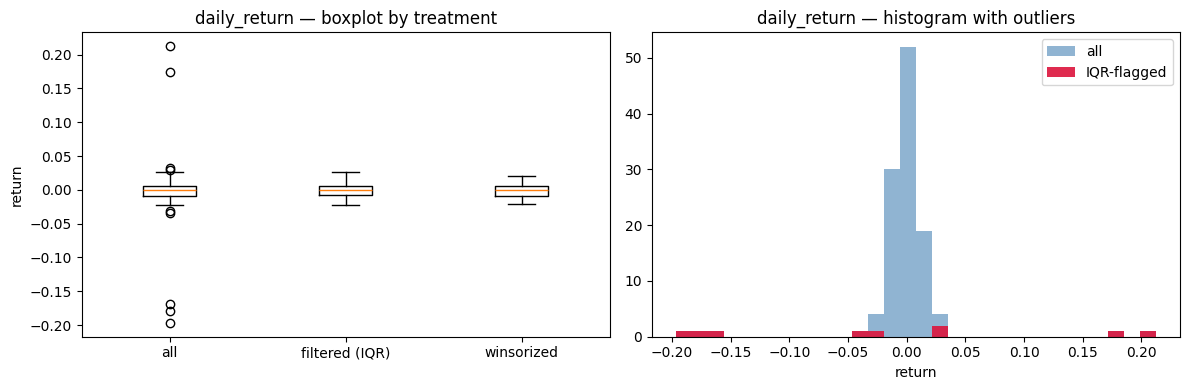

In [8]:
winsor = outliers.winsorize_series(df[target_col])  # 5%/95% clip — "keep but cap"

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Boxplot: all vs IQR-filtered vs winsorized
bp = axes[0].boxplot([df[target_col], df.loc[~df['outlier_iqr'], target_col], winsor])
axes[0].set_xticklabels(['all', 'filtered (IQR)', 'winsorized'])
axes[0].set_title(f'{target_col} — boxplot by treatment')
axes[0].set_ylabel('return')

# Histogram with IQR-flagged values highlighted
axes[1].hist(df[target_col], bins=30, alpha=0.6, color='steelblue', label='all')
axes[1].hist(df.loc[df['outlier_iqr'], target_col], bins=30, alpha=0.9,
             color='crimson', label='IQR-flagged')
axes[1].set_title(f'{target_col} — histogram with outliers')
axes[1].set_xlabel('return'); axes[1].legend()

plt.tight_layout(); plt.show()

## 5) Sensitivity analysis — summary stats

**Treatment A.** Does the *summary* of `daily_return` change when outliers are removed
or capped?

In [9]:
def _summary(s):
    return pd.Series({'mean': s.mean(), 'median': s.median(), 'std': s.std()})

summ = pd.DataFrame({
    'all':          _summary(df[target_col]),
    'filtered_iqr': _summary(df.loc[~df['outlier_iqr'], target_col]),
    'winsorized':   _summary(winsor),
}).T
summ.round(6)

,mean,median,std
all,-0.001434,-0.000187,0.040579
filtered_iqr,-0.000039,-0.000100,0.009443
winsorized,-0.000251,-0.000187,0.010623


## 5b) Sensitivity analysis — linear regression

**Treatment B.** The two return columns are correlated (true slope ≈ 0.6), so I regress
`daily_return_2` on `daily_return` and compare coefficients, R² and MAE across the same
three treatments.

> **Read the R² column carefully** — a *lower* R² after filtering does **not** mean the
> model got worse (see the reflection).

In [10]:
resp_col = 'daily_return_2'

def _fit(X, y):
    m = LinearRegression().fit(X, y)
    pred = m.predict(X)
    return pd.Series({
        'slope':     m.coef_[0],
        'intercept': m.intercept_,
        'r2':        r2_score(y, pred),
        'mae':       mean_absolute_error(y, pred),
    })

X_all = df[[target_col]].to_numpy()
y_all = df[resp_col].to_numpy()
X_flt = df.loc[~df['outlier_iqr'], [target_col]].to_numpy()
y_flt = df.loc[~df['outlier_iqr'], resp_col].to_numpy()

# Winsorize BOTH columns consistently. Capping only the predictor while the response
# keeps its shocks breaks the relationship (slope balloons to ~1.47) — see reflection.
winsor_x = outliers.winsorize_series(df[target_col])
winsor_y = outliers.winsorize_series(df[resp_col])

results = pd.DataFrame([
    _fit(X_all, y_all),
    _fit(X_flt, y_flt),
    _fit(winsor_x.to_numpy().reshape(-1, 1), winsor_y.to_numpy()),
], index=['all', 'filtered_iqr', 'winsorized'])
results.round(6)

,slope,intercept,r2,mae
all,0.605869,0.000201,0.961859,0.003951
filtered_iqr,0.589679,-0.000049,0.573566,0.003851
winsorized,0.649705,-0.000017,0.689444,0.003741


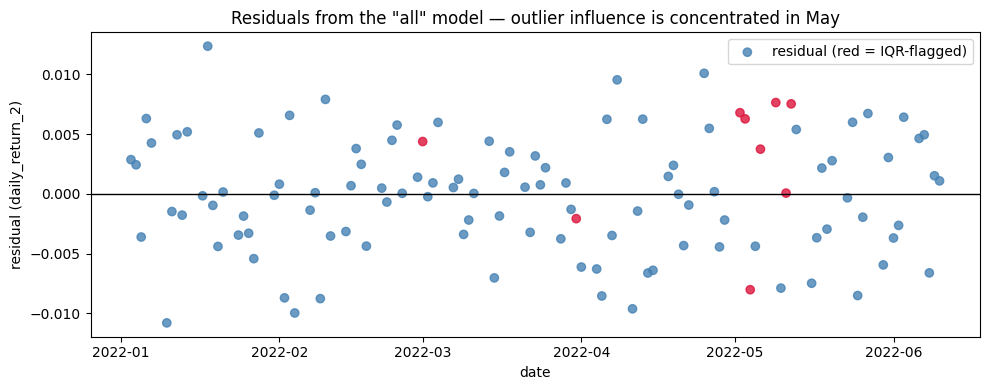

In [11]:
# Residuals from the "all" model — do the flagged points carry most of the error?
m_all = LinearRegression().fit(X_all, y_all)
resid = y_all - m_all.predict(X_all)

fig, ax = plt.subplots(figsize=(10, 4))
ax.scatter(df['date'], resid, c=np.where(df['outlier_iqr'], 'crimson', 'steelblue'),
           alpha=0.8, label='residual (red = IQR-flagged)')
ax.axhline(0, color='k', lw=1)
ax.set_xlabel('date'); ax.set_ylabel(f'residual ({resp_col})')
ax.set_title('Residuals from the "all" model — outlier influence is concentrated in May')
ax.legend()
plt.tight_layout(); plt.show()

In [12]:
# Save a processed copy (flags + winsorized column) for reproducibility
df_out = df.copy()
df_out['daily_return_winsorized'] = winsor
out_path = os.path.join(processed_dir, 'outliers_homework_processed.csv')
df_out.to_csv(out_path, index=False)
print('Saved ->', out_path)

Saved -> data/processed/outliers_homework_processed.csv


## 6) Reflection

### Methods & thresholds (and why)
I ran two detectors on `daily_return` — **IQR with `k=1.5`** (the conventional "mild
outlier" fence) and **Z-score with `threshold=3`** (the conventional "extreme" cutoff) —
plus **winsorizing at 5%/95%** as a keep-but-cap alternative. IQR is quartile-based and
robust to skew; Z-score is the natural choice when the bulk looks roughly normal.

### Assumptions behind the choices
* **Z-score assumes a roughly normal bulk**, and that its mean/std describe the *typical*
  observation. Those moments are themselves inflated by the very outliers we seek (a
  masking risk).
* **IQR assumes the quartiles summarize the distribution.** Its fences are computed on the
  full series; because the five shocks are only 5 of 115 points, they barely move Q1/Q3,
  so the IQR fence stays very tight.
* **Winsorizing assumes the extremes are genuine-but-overly-influential** values worth
  capping, not errors to delete.

### Observed impact
* **Z-score flagged exactly the five injected shocks** (min |z| = 4.1 among shocks vs 0.8
  max among non-shocks — a clean gap). **IQR flagged 9** values: the same five shocks plus
  four milder draws (2022-03-01, 03-31, 05-04, 05-11) that sit outside the tight IQR fence
  (±0.029) yet are still normal (≤ 0.83σ). IQR is *too sensitive* here, not wrong — its fence
  is calibrated for a symmetric bulk that the injected shocks made artificially narrow.
* **Summary stats:** removing outliers collapses `std` from **0.0406 → 0.0094** (~4.3×) and
  moves the mean from **−0.00143 → −0.00004**; the **median barely moves** (−0.00019 → −0.00010),
  confirming its robustness. Winsorizing preserves the full sample and lands in between
  (std 0.0106).
* **Regression:** the slope is robust (all **0.606** vs filtered **0.590**; true ≈ 0.6). **R²
  falls from 0.96 → 0.57** — not because the model worsened, but because the five high-leverage
  shocks were the largest, easiest variance to explain; deleting them deletes the "easy" R².
  MAE is essentially unchanged (0.00395 → 0.00385). Winsorizing **both** columns gives the
  lowest MAE (0.0037) at slope 0.65 / R² 0.69.

### Risks if the assumptions are wrong
* The four *extra* IQR flags are **genuine observed returns, not data errors** — in finance a
  large return is usually a real event (news, earnings). Blindly deleting them would
  understate tail risk and volatility. That is why I prefer flagging + reporting over
  auto-deleting.
* **Z-score masking:** with *many* outliers, the inflated std would hide some of them. Here
  there are few, so threshold 3 cleanly separates them; on heavier-tailed data I'd trust IQR
  more.
* **Winsorizing consistency:** capping only the predictor while leaving the response's shocks
  uncapped breaks the X→Y relationship (slope balloons to ~1.47); the cap must be applied to
  both columns — or, if only one variable is genuinely extreme, to that variable with the
  distortion called out explicitly.